# K-IFRS RAG 검색 테스트

## 구성
- **Part 1**: Dense 검색 RAG (Qdrant + KURE-v1 + LangGraph)
- **Part 2**: Hybrid 검색 RAG (BM25 kiwipiepy + Dense + EnsembleRetriever)

### 사전 준비
- Qdrant에 K-IFRS 데이터 적재 완료 (이전 세션에서 수행)
- KURE-v1 임베딩 모델 다운로드 완료
- 청킹된 JSON 파일 존재

---
## Part 0: 환경 설정

In [2]:
from dotenv import load_dotenv

load_dotenv()

True

In [3]:
# ==============================================
# 📌 경로 설정 — 본인 환경에 맞게 수정할 것
# ==============================================

# Qdrant 로컬 DB 경로 (이전 세션에서 생성한 것)
QDRANT_PATH = "./qdrant_storage_test"

# 청킹된 JSON 파일 경로 (BM25에 로딩할 때 사용)
CHUNKS_DIR = "./output_test/chunks"

# Qdrant 컬렉션 이름
CHILD_COLLECTION = "kifrs_chunks"
PARENT_COLLECTION = "kifrs_parents"

# 임베딩 모델
EMBEDDING_MODEL = "nlpai-lab/KURE-v1"

---
## Part 1: Dense 검색 RAG

### 1-1. 임베딩 모델 로딩

KURE-v1은 BGE-M3 기반, 1024차원, 최대 8192토큰.
최초 실행 시 HuggingFace에서 ~2.3GB 다운로드 발생.

In [4]:
# !pip install langchain-huggingface langchain-qdrant

In [5]:
from langchain_huggingface import HuggingFaceEmbeddings

embedding = HuggingFaceEmbeddings(
    model_name=EMBEDDING_MODEL,
    model_kwargs={'device': 'cpu'},   # GPU 있으면 'cuda'로 변경
    encode_kwargs={'normalize_embeddings': True}
)

# 로딩 확인
test_vec = embedding.embed_query("테스트")
print(f"임베딩 차원: {len(test_vec)}")

c:\Study\LangChain\2. AI Agent 개발\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


임베딩 차원: 1024


### 1-2. Qdrant Dense Retriever 구성

In [6]:
from langchain_qdrant import QdrantVectorStore
from langchain_core.documents import Document
from qdrant_client import QdrantClient

# ── Qdrant flat payload → LangChain Document 변환 오버라이드 ──
# embedder.py에서 qdrant_client로 직접 적재한 payload 구조:
#   {chunk_id, parent_id, content, standard_id, section_type, para_number, ...}
# QdrantVectorStore 기본 기대 구조:
#   {page_content: "...", metadata: {...}}
# → content 외 모든 필드를 metadata로 매핑하도록 오버라이드

@staticmethod
def _document_from_flat_payload(scored_point, collection_name, content_payload_key, metadata_payload_key):
    """flat payload의 모든 필드(content 제외)를 metadata로 매핑"""
    payload = scored_point.payload
    metadata = {k: v for k, v in payload.items() if k != content_payload_key}
    metadata["_id"] = scored_point.id
    metadata["_collection_name"] = collection_name
    return Document(
        page_content=payload.get(content_payload_key, ""),
        metadata=metadata,
    )

QdrantVectorStore._document_from_point = _document_from_flat_payload

# Qdrant 클라이언트 (로컬 파일 모드)
qdrant_client = QdrantClient(path=QDRANT_PATH)

# LangChain Retriever로 감싸기
vectorstore = QdrantVectorStore(
    client=qdrant_client,
    collection_name=CHILD_COLLECTION,
    embedding=embedding,
    content_payload_key="content",  # payload의 content 키 사용
)

dense_retriever = vectorstore.as_retriever(
    search_type='similarity',
    search_kwargs={'k': 10}
)

# 검색 테스트
test_docs = dense_retriever.invoke("유형자산 감가상각 방법")
print(f"검색된 문서 수: {len(test_docs)}")
for doc in test_docs:
    print(f"  - 문단 {doc.metadata.get('para_number', 'N/A')}: {doc.page_content[:80]}...")

검색된 문서 수: 10
  - 문단 59: 59 토지의 원가에 해체, 제거 및 복구원가가 포함된 경우에는 그러한

원가를 관련 경제적효익이 유입되는 기간에 감가상각한다 . 경우에

따라서...
  - 문단 62: 62 유형자산의 감가상각대상금액을 내용연수 동안 체계적으로 배부

하기 위해 다양한 방법을 사용할 수 있다 . 이러한 감가상각방법에

는 정액법...
  - 문단 45: 45 유형자산을 구성하고 있는 유의적인 부분에 해당 유형자산의 다

른 유의적인 부분과 동일한 내용연수 및 감가상각방법을 적용하

는 수가 있다...
  - 문단 55: 55 유형자산의 감가상각은 자산이 사용가능한 때부터 시작한다 . 즉,

경영진이 의도하는 방식으로 자산을 가동하는 데 필요한 장소와

상태에 이...
  - 문단 1002: 1002 호 참조 ), 개발활동에 사용되는 유형자산의 감가상각액은 기

업회계기준서 제 1038 호 ‘ 무형자산 ’ 에 따라 해당 무형자산의 원...
  - 문단 46: 46 유형자산의 일부를 별도로 구분하여 감가상각하는 경우에는 동일

한 유형자산을 구성하고 있는 나머지 부분도 별도로 구분하여 감

가상각한다 ...
  - 문단 44: 44 유형자산의 원가는 그 유형자산을 구성하고 있는 유의적인 부분

에 배분하여 각 부분별로 감가상각한다 . 예를 들면, 항공기 동체

와 엔진...
  - 문단 47: 47 유형자산의 전체원가에 비교하여 해당 원가가 유의적이지 않은

부분도 별도로 분리하여 감가상각할 수 있다 .

각 기간의 감가상각액은 다른 ...
  - 문단 54: 54 유형자산의 잔존가치는 해당 자산의 장부금액과 같거나 큰 금액

으로 증가할 수도 있다 . 이 경우에는 자산의 잔존가치가 장부금액

보다 작...
  - 문단 42: 42 유형자산의 재평가로 인한 법인세효과는 기업회계기준서 제 1012

호 ‘ 법인세 ' 에 따라 인식하고 공시한다 .

감가상각

유형자산을 ...


### 1-3. LLM 설정

비용 최적화: 개발/테스트에는 Haiku 사용.

In [7]:
from langchain_anthropic import ChatAnthropic

# 개발용 (저렴)
llm = ChatAnthropic(
    model='claude-haiku-4-5-20251001',
    temperature=0.1
)

# 품질 비교용 (필요 시 주석 해제)
# llm = ChatAnthropic(
#     model='claude-sonnet-4-5-20250929',
#     temperature=0.1
# )

### 1-4. Dense RAG 체인 (LangGraph)

강의 패턴과 동일한 구조:  
`START → retrieve → generate → END`

In [8]:
from typing_extensions import List, TypedDict
from langchain_core.documents import Document


class RAGState(TypedDict):
    query: str
    context: List[Document]
    answer: str

In [9]:
from langchain_core.prompts import ChatPromptTemplate

# K-IFRS 특화 프롬프트
RAG_PROMPT = ChatPromptTemplate.from_template(
    """당신은 K-IFRS(한국채택국제회계기준) 전문가입니다.
아래 제공된 기준서 문단을 근거로 질문에 답변하세요.

규칙:
- 반드시 제공된 기준서 내용만을 근거로 답변할 것
- 해당 문단 번호를 인용할 것 (예: "문단 62에 따르면...")
- 제공된 내용으로 답변할 수 없으면 솔직히 "제공된 기준서에 해당 내용이 없습니다"라고 답할 것

참고 기준서:
{context}

질문: {question}
답변:"""
)

In [10]:
def retrieve(state: RAGState):
    """Dense 검색으로 관련 문단 조회"""
    query = state['query']
    docs = dense_retriever.invoke(query)
    return {'context': docs}


def generate(state: RAGState):
    """검색된 문단 기반으로 답변 생성"""
    context = state['context']
    query = state['query']
    
    # context를 문자열로 포맷팅 (문단번호 포함)
    context_str = "\n\n".join([
        f"[{doc.metadata.get('section_type', '')} - "
        f"문단 {doc.metadata.get('para_number', 'N/A')}]\n"
        f"{doc.page_content}"
        for doc in context
    ])
    
    rag_chain = RAG_PROMPT | llm
    response = rag_chain.invoke({
        'context': context_str,
        'question': query
    })
    return {'answer': response.content}

In [11]:
from langgraph.graph import StateGraph, START, END

# Dense RAG 그래프
dense_graph_builder = StateGraph(RAGState)
dense_graph_builder.add_node('retrieve', retrieve)
dense_graph_builder.add_node('generate', generate)
dense_graph_builder.add_edge(START, 'retrieve')
dense_graph_builder.add_edge('retrieve', 'generate')
dense_graph_builder.add_edge('generate', END)

dense_rag = dense_graph_builder.compile()

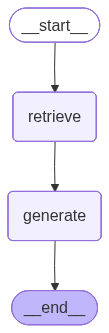

In [12]:
from IPython.display import display, Image

display(Image(dense_rag.get_graph().draw_mermaid_png()))

### 1-5. Dense RAG 테스트

In [13]:
# 테스트 쿼리 3개
test_queries = [
    "유형자산의 감가상각 방법에는 어떤 것들이 있나요?",
    "원가모형과 재평가모형의 차이점을 설명해주세요",
    "유형자산을 제거할 때 손익은 어떻게 처리하나요?",
]

In [14]:
# 첫 번째 쿼리 테스트
result = dense_rag.invoke({'query': test_queries[0]})

print("=" * 60)
print(f"Q: {test_queries[0]}")
print("=" * 60)
print(f"\n📄 검색된 문단 ({len(result['context'])}건):")
for doc in result['context']:
    sec = doc.metadata.get('section_type', '')
    para = doc.metadata.get('para_number', 'N/A')
    print(f"  [{sec}] 문단 {para}: {doc.page_content[:60]}...")
print(f"\n💬 답변:\n{result['answer']}")

Q: 유형자산의 감가상각 방법에는 어떤 것들이 있나요?

📄 검색된 문단 (10건):
  [main] 문단 59: 59 토지의 원가에 해체, 제거 및 복구원가가 포함된 경우에는 그러한

원가를 관련 경제적효익이 유입되는 기...
  [main] 문단 62: 62 유형자산의 감가상각대상금액을 내용연수 동안 체계적으로 배부

하기 위해 다양한 방법을 사용할 수 있다 ...
  [main] 문단 45: 45 유형자산을 구성하고 있는 유의적인 부분에 해당 유형자산의 다

른 유의적인 부분과 동일한 내용연수 및 ...
  [main] 문단 55: 55 유형자산의 감가상각은 자산이 사용가능한 때부터 시작한다 . 즉,

경영진이 의도하는 방식으로 자산을 가...
  [main] 문단 1002: 1002 호 참조 ), 개발활동에 사용되는 유형자산의 감가상각액은 기

업회계기준서 제 1038 호 ‘ 무형...
  [main] 문단 46: 46 유형자산의 일부를 별도로 구분하여 감가상각하는 경우에는 동일

한 유형자산을 구성하고 있는 나머지 부분...
  [main] 문단 None: 유형자산의 각 유형별로 다음사항을 공시하여야 한다

총장부금액을 결정하는 데 사용한 측정기준

감가상각방법
...
  [bc] 문단 None: 이 기준서는 유형자산에 대한 회계처리와 공시에 대한 사항을 정하고 있다 .

적용범위

이 기준서는 적용범위...
  [main] 문단 44: 44 유형자산의 원가는 그 유형자산을 구성하고 있는 유의적인 부분

에 배분하여 각 부분별로 감가상각한다 ....
  [main] 문단 49: 49 각 기간의 감가상각액은 일반적으로 당기손익으로 인식한다 . 그러

나 유형자산에 내재된 미래경제적효익이...

💬 답변:
문단 62에 따르면, 유형자산의 감가상각대상금액을 내용연수 동안 체계적으로 배부하기 위해 다양한 방법을 사용할 수 있으며, 주요 감가상각방법은 다음과 같습니다:

1. **정액법**: 잔존가치가 변동하지 않는다고 가정할 때 자산의 내용연수 동안 매 기간

In [15]:
# 두 번째 쿼리 테스트
result = dense_rag.invoke({'query': test_queries[1]})

print("=" * 60)
print(f"Q: {test_queries[0]}")
print("=" * 60)
print(f"\n📄 검색된 문단 ({len(result['context'])}건):")
for doc in result['context']:
    sec = doc.metadata.get('section_type', '')
    para = doc.metadata.get('para_number', 'N/A')
    print(f"  [{sec}] 문단 {para}: {doc.page_content[:60]}...")
print(f"\n💬 답변:\n{result['answer']}")

Q: 유형자산의 감가상각 방법에는 어떤 것들이 있나요?

📄 검색된 문단 (10건):
  [main] 문단 None: 를 회계정책으로 선택하여 유형자산의 유형별로 동일하게 적용한

다

29A 일부 기업은 투자자에게 펀드 내의...
  [bc] 문단 BC103: BC103 이 개정에서는 기업이 생산용식물에 IAS 16 에 따라 원가모형이나

재평가모형 가운데 어느 하나...
  [bc] 문단 BC104: BC104 따라서 문단 BC106~BC117 의 예상 영향 분석에서는 IAS 41 의 공

정가치모형과 비교...
  [bc] 문단 BC107: BC107 현행 IFRS 채택기업이 생산용식물에 IAS 16 의 원가모형을 적용하

기로 선택했다고 가정할 ...
  [bc] 문단 BC16: BC16 IASB 는 IAS 16 의 최초 측정 규정은 후속적으로 원가모형이나 재

평가모형 중 어느 것을 ...
  [bc] 문단 BC25C: BC25C 제출된 의견에서는 재평가 전에 잔존가치, 내용연수 또는 감가상

각방법이 재추정된 경우에는 총장부...
  [bc] 문단 BC25H: BC25H 또한, IASB 는 문단 35(1) 의 두 번째 문장에서 비례적으로 수정하

는 방법이 지수를 적...
  [main] 문단 10: 10 유형자산과 관련된 모든 원가는 그 발생시점에 인식원칙을 적용

하여 평가한다 . 이러한 원가에는 유형자...
  [bc] 문단 BC92: BC92 IAS 16 에서는 기업이 유형자산의 유형별로 원가모형이나 재평가

모형을 선택하도록 허용한다 . ...
  [main] 문단 35: 35 유형자산을 재평가할 때, 그 자산의 장부금액을 재평가금액으로

조정한다 . 재평가일에 그 자산을 다음 ...

💬 답변:
# 원가모형과 재평가모형의 차이점

제공된 기준서를 근거로 두 모형의 차이점을 설명하겠습니다.

## 1. 후속 측정 방법

**원가모형:**
문단 31에 따르면, "최초 인식 후에 유형자산은 원가에서 감가상각누계액과 손상차손누계액을 차감한 금액을

In [16]:
# 세 번째 쿼리 테스트
result = dense_rag.invoke({'query': test_queries[2]})

print("=" * 60)
print(f"Q: {test_queries[0]}")
print("=" * 60)
print(f"\n📄 검색된 문단 ({len(result['context'])}건):")
for doc in result['context']:
    sec = doc.metadata.get('section_type', '')
    para = doc.metadata.get('para_number', 'N/A')
    print(f"  [{sec}] 문단 {para}: {doc.page_content[:60]}...")
print(f"\n💬 답변:\n{result['answer']}")

Q: 유형자산의 감가상각 방법에는 어떤 것들이 있나요?

📄 검색된 문단 (10건):
  [main] 문단 None: 유형자산의 장부금액은 다음과 같은 때에 제거한다

처분하는 때

사용이나 처분을 통하여 미래경제적효익이 기대...
  [main] 문단 72: 72 유형자산의 제거에서 생기는 손익에 포함되는 대가 ( 금액 ) 는 기업

회계기준서 제 1115 호 문단...
  [main] 문단 70: 70 문단 7 의 인식원칙에 따라 유형자산 항목의 일부에 대한 대체원

가를 자산의 장부금액으로 인식하는 경...
  [main] 문단 69: 69 유형자산은 여러 방법 ( 예 : 판매, 금융리스의 체결, 기부 ) 으로 처분

할 수 있다 . 유형자산...
  [main] 문단 66: 66 유형자산과 관련된 손상차손이나 기타 손실, 제 3 자에 대한 보상청

구나 그 보상금의 수령 그리고 대...
  [bc] 문단 BC35B: BC35B IASB 는 이 기준서가 유형자산의 제거에서 발생하는 차익을 수익

으로 분류하는 것을 금지하고 ...
  [main] 문단 41: 41 어떤 유형자산 항목과 관련하여 자본에 계상된 재평가잉여금은

그 자산이 제거될 때 이익잉여금으로 직접 ...
  [bc] 문단 None: 이 기준서는 유형자산에 대한 회계처리와 공시에 대한 사항을 정하고 있다 .

적용범위

이 기준서는 적용범위...
  [main] 문단 47: 47 유형자산의 전체원가에 비교하여 해당 원가가 유의적이지 않은

부분도 별도로 분리하여 감가상각할 수 있다...
  [main] 문단 57: 57 유형자산의 내용연수는 자산으로부터 기대되는 효용에 따라 결정

된다 . 유형자산은 기업의 자산관리정책에...

💬 답변:
# 유형자산 제거 시 손익 처리

## 손익 인식 방법

문단 72에 따르면, **유형자산의 제거에서 생기는 손익은 순매각금액과 장부금액의 차이로 결정**됩니다.

구체적으로:
- **손익에 포함되는 대가(금액)**는 기업회계기준서 제1115호 문단 47

---
## Part 2: Hybrid 검색 RAG (BM25 + Dense)

### 왜 하이브리드가 필요한가?

Dense 검색은 의미(semantic) 매칭에 강하지만,  
정확한 기준서 번호("제1016호")나 회계 용어("감가상각누계액")는 놓칠 수 있습니다.

BM25는 키워드 매칭이라 이런 정확한 용어 검색에 강합니다.  
둘을 결합하면 recall이 올라갑니다.

### 핵심 변경점
- `kiwipiepy`로 한국어 형태소 분석 → BM25 토크나이저로 사용
- `EnsembleRetriever`로 BM25 + Dense 결합 (0.4 / 0.6)
- retrieve 노드만 교체, generate 노드는 동일

### 2-1. 청킹된 JSON에서 Document 객체 복원

BM25Retriever는 `Document` 리스트를 받아야 합니다.  
이전 세션에서 저장한 청킹 JSON 파일을 읽어서 복원합니다.

⚠️ **강의와 다른 점**: 강의에서는 `splits` 변수가 메모리에 있었지만,  
우리는 JSON 파일에서 로딩해야 합니다.

In [17]:
import json
import glob
from langchain_core.documents import Document


def load_chunks_as_documents(chunks_dir: str) -> list[Document]:
    """청킹된 JSON 파일들을 LangChain Document로 변환"""
    documents = []
    
    for json_path in sorted(glob.glob(f"{chunks_dir}/*.json")):
        with open(json_path, 'r', encoding='utf-8') as f:
            data = json.load(f)
        
        # JSON 구조: {standard_id, processed_at, parents, children}
        children = data.get('children', []) if isinstance(data, dict) else data
        
        for chunk in children:
            # metadata가 중첩 dict 안에 있음
            meta = chunk.get('metadata', {})
            
            doc = Document(
                page_content=chunk['content'],
                metadata={
                    'chunk_id': chunk.get('chunk_id', ''),
                    'parent_id': chunk.get('parent_id', ''),
                    'standard_id': meta.get('standard_id', ''),
                    'section_type': meta.get('section_type', ''),
                    'para_number': meta.get('para_number', ''),
                    'cross_refs': meta.get('cross_refs', []),
                }
            )
            documents.append(doc)
    
    return documents


child_docs = load_chunks_as_documents(CHUNKS_DIR)
print(f"로딩된 child Document 수: {len(child_docs)}")
print(f"샘플: {child_docs[0].page_content[:80]}...")

로딩된 child Document 수: 244
샘플: - 4

                 - 5

나 기준서를 적용하는 데 편의를 제공하기 위해 제시된다

                  - 6...


### 2-2. kiwipiepy BM25 Retriever 구성

한국어는 영어와 달리 공백 기반 토큰화가 안 됩니다.  
"감가상각누계액"을 "감가상각" + "누계액"으로 분리해야 BM25가 제대로 작동합니다.

`kiwipiepy`는 한국어 형태소 분석기로, BM25의 전처리기(preprocessor)로 사용합니다.

In [18]:
from kiwipiepy import Kiwi

# venv 경로에 한글 포함 시 C++ 라이브러리가 모델 파일을 못 여는 문제 우회
try:
    kiwi = Kiwi()
except Exception:
    import ctypes, kiwipiepy_model
    buf = ctypes.create_unicode_buffer(500)
    ctypes.windll.kernel32.GetShortPathNameW(kiwipiepy_model.get_model_path(), buf, 500)
    kiwi = Kiwi(model_path=buf.value)

def kiwi_tokenize(text: str) -> list[str]:
    """kiwipiepy로 한국어 형태소 분석 후 명사/동사/형용사만 추출"""
    tokens = kiwi.tokenize(text)
    # NNG(일반명사), NNP(고유명사), VV(동사), VA(형용사), SN(숫자)
    valid_tags = {'NNG', 'NNP', 'VV', 'VA', 'SN'}
    return [t.form for t in tokens if t.tag in valid_tags]


# 토크나이저 테스트
test_text = "유형자산의 감가상각누계액을 차감한 장부금액"
print(f"원문: {test_text}")
print(f"토큰: {kiwi_tokenize(test_text)}")

원문: 유형자산의 감가상각누계액을 차감한 장부금액
토큰: ['유형', '자산', '감가상각', '누계', '액', '차감', '장부', '금액']


In [21]:
from langchain_community.retrievers import BM25Retriever

bm25_retriever = BM25Retriever.from_documents(
    child_docs,
    k=10,                             # 하이브리드에서 RRF 합산 전이므로 넉넉히
    preprocess_func=kiwi_tokenize     # 한국어 형태소 분석기 적용
)

# BM25 단독 테스트
bm25_results = bm25_retriever.invoke("감가상각누계액")
print(f"BM25 검색 결과: {len(bm25_results)}건")
for doc in bm25_results[:3]:
    print(f"  [{doc.metadata.get('section_type')}] "
          f"문단 {doc.metadata.get('para_number')}: "
          f"{doc.page_content[:60]}...")

BM25 검색 결과: 10건
  [bc] 문단 BC25D: BC25D 이러한 경우, 유형자산의 항목을 재평가할 때 감가상각누계액을

계산하는 방법에 대해 상반된 견해가...
  [bc] 문단 BC25E: BC25E 문단 6 에서 ‘ 장부금액 ’ 의 정의는 ‘ 감가상각누계액과 손상차손누계

액을 차감한 후 인식되...
  [bc] 문단 BC25J: BC25J IASB 는 문단 35(1) 에 재평가 시점에 감가상각누계액을 조정할 때

손상차손누계액을 고려할...


### 2-3. EnsembleRetriever (Hybrid)

강의에서 사용한 `EnsembleRetriever`를 그대로 적용합니다.  
내부적으로 **Reciprocal Rank Fusion (RRF)** 를 사용하여 두 검색 결과를 합산합니다.

가중치: BM25 0.4 / Dense 0.6 (확정된 스택 기준)  
→ 나중에 AutoRAG 벤치마킹으로 최적 비율을 찾을 예정

In [22]:
from langchain.retrievers import EnsembleRetriever

# Dense retriever의 k도 넉넉히 설정 (RRF 합산 전)
dense_retriever_for_hybrid = vectorstore.as_retriever(
    search_type='similarity',
    search_kwargs={'k': 10}
)

hybrid_retriever = EnsembleRetriever(
    retrievers=[bm25_retriever, dense_retriever_for_hybrid],
    weights=[0.4, 0.6]
)

print("✅ Hybrid Retriever 구성 완료 (BM25 0.4 + Dense 0.6)")

✅ Hybrid Retriever 구성 완료 (BM25 0.4 + Dense 0.6)


### 2-4. Hybrid RAG 체인 (LangGraph)

retrieve 노드만 교체합니다. generate 노드는 동일.

In [23]:
def hybrid_retrieve(state: RAGState):
    """Hybrid 검색 (BM25 + Dense)"""
    query = state['query']
    docs = hybrid_retriever.invoke(query)
    # EnsembleRetriever는 중복 제거 + RRF 스코어 순 정렬 후 반환
    # 상위 5개만 LLM에 전달 (컨텍스트 길이 관리)
    return {'context': docs[:5]}


# Hybrid RAG 그래프
hybrid_graph_builder = StateGraph(RAGState)
hybrid_graph_builder.add_node('retrieve', hybrid_retrieve)
hybrid_graph_builder.add_node('generate', generate)  # Part 1의 generate 재사용
hybrid_graph_builder.add_edge(START, 'retrieve')
hybrid_graph_builder.add_edge('retrieve', 'generate')
hybrid_graph_builder.add_edge('generate', END)

hybrid_rag = hybrid_graph_builder.compile()
print("✅ Hybrid RAG 그래프 컴파일 완료")

✅ Hybrid RAG 그래프 컴파일 완료


### 2-5. Dense vs Hybrid 비교 테스트

같은 쿼리를 두 방식으로 돌려서 검색 결과와 답변 품질을 비교합니다.

In [24]:
comparison_queries = [
    # 의미 검색이 유리한 쿼리
    "유형자산의 감가상각 방법에는 어떤 것들이 있나요?",
    
    # 정확한 용어가 포함된 쿼리 (BM25가 유리)
    "감가상각누계액 표시 방법",
    
    # 기준서 번호 참조 (BM25가 유리)
    "제1016호에서 재평가모형 적용 요건",
    
    # 복합 쿼리
    "유형자산 제거 시 손익 인식 시점과 방법",
]

In [25]:
def compare_search(query: str):
    """Dense와 Hybrid 검색 결과를 나란히 비교"""
    print("=" * 70)
    print(f"🔍 Query: {query}")
    print("=" * 70)
    
    # Dense 검색
    dense_docs = dense_retriever.invoke(query)
    dense_paras = [d.metadata.get('para_number', '?') for d in dense_docs]
    
    # Hybrid 검색
    hybrid_docs = hybrid_retriever.invoke(query)[:5]
    hybrid_paras = [d.metadata.get('para_number', '?') for d in hybrid_docs]
    
    print(f"\n  📘 Dense  문단: {dense_paras}")
    print(f"  📗 Hybrid 문단: {hybrid_paras}")
    
    # 차이 분석
    dense_set = set(dense_paras)
    hybrid_set = set(hybrid_paras)
    only_dense = dense_set - hybrid_set
    only_hybrid = hybrid_set - dense_set
    
    if only_hybrid:
        print(f"  ➕ Hybrid에서만 검색된 문단: {only_hybrid}")
    if only_dense:
        print(f"  ➖ Dense에서만 검색된 문단: {only_dense}")
    if not only_hybrid and not only_dense:
        print(f"  🟰 동일한 문단 검색됨")
    
    print()


for q in comparison_queries:
    compare_search(q)

🔍 Query: 유형자산의 감가상각 방법에는 어떤 것들이 있나요?

  📘 Dense  문단: ['59', '62', '45', '55', '1002', '46', None, None, '44', '49']
  📗 Hybrid 문단: ['59', '45', '62', '1002', '55']
  ➖ Dense에서만 검색된 문단: {None, '44', '49', '46'}

🔍 Query: 감가상각누계액 표시 방법

  📘 Dense  문단: ['BC25J', '75', 'BC25I', 'BC25D', '62', None, 'BC25A', 'BC25F', '42', '1002']
  📗 Hybrid 문단: ['BC25D', 'BC25J', '75', None, 'BC25I']
  ➖ Dense에서만 검색된 문단: {'42', 'BC25F', 'BC25A', '1002', '62'}

🔍 Query: 제1016호에서 재평가모형 적용 요건

  📘 Dense  문단: ['BC105', '76', None, None, '42', 'BC103', None, 'BC92', 'BC16', 'BC50']
  📗 Hybrid 문단: [None, 'BC103', 'BC105', None, 'BC16']
  ➖ Dense에서만 검색된 문단: {'BC50', 'BC92', '42', '76'}

🔍 Query: 유형자산 제거 시 손익 인식 시점과 방법

  📘 Dense  문단: ['70', None, None, '66', '69', '72', 'BC34', 'BC35B', 'BC35', '41']
  📗 Hybrid 문단: [None, '70', None, '66', '69']
  ➖ Dense에서만 검색된 문단: {'72', 'BC34', '41', 'BC35', 'BC35B'}



In [26]:
# 답변 품질 비교 (비용 주의: 쿼리당 LLM 호출 2회)
compare_query = "감가상각누계액 표시 방법"

dense_result = dense_rag.invoke({'query': compare_query})
hybrid_result = hybrid_rag.invoke({'query': compare_query})

print("=" * 70)
print(f"Q: {compare_query}")
print("=" * 70)
print(f"\n📘 [Dense RAG 답변]")
print(f"검색 문단: {[d.metadata.get('para_number') for d in dense_result['context']]}")
print(dense_result['answer'])
print(f"\n📗 [Hybrid RAG 답변]")
print(f"검색 문단: {[d.metadata.get('para_number') for d in hybrid_result['context']]}")
print(hybrid_result['answer'])

Q: 감가상각누계액 표시 방법

📘 [Dense RAG 답변]
검색 문단: ['BC25J', '75', 'BC25I', 'BC25D', '62', None, 'BC25A', 'BC25F', '42', '1002']
# 감가상각누계액 표시 방법

제공된 기준서에서 감가상각누계액의 표시 방법에 대해 직접적으로 규정하는 내용은 찾을 수 없습니다.

다만, 관련된 내용은 다음과 같습니다:

## 공시 요구사항

**문단 75**에 따르면, 다음 사항을 공시해야 합니다:
- ⑵ 기말의 감가상각누계액

또한 공시 규정(문단 29)에서는:
- "기초와 기말의 총장부금액 감가상각누계액 손상차손누계액을 합한 금액"을 공시하도록 요구하고 있습니다.

## 재평가 시 감가상각누계액 조정

**문단 BC25I**에 따르면, 재평가 시점에 감가상각누계액은 "손상차손누계액을 고려한 후 총장부금액과 장부금액의 차이로 계산"되어야 합니다.

감가상각누계액의 **표시 형식**(예: 차감 표시, 별도 표시 등)에 대한 구체적인 규정은 **제공된 기준서에 해당 내용이 없습니다.**

📗 [Hybrid RAG 답변]
검색 문단: ['BC25D', 'BC25J', '75', None, 'BC25I']
# 감가상각누계액 표시 방법

제공된 기준서에서 감가상각누계액의 표시 방법에 대해 다음과 같이 규정하고 있습니다.

## 재평가 시 감가상각누계액 조정 방법

**문단 BC25I**에 따르면, 유형자산을 재평가할 때 감가상각누계액은 다음과 같이 계산됩니다:

> "감가상각누계액은 손상차손누계액을 고려한 후 **총장부금액과 장부금액의 차이로 계산**한다"

## 공시 요구사항

**문단 75**에 따르면 다음 사항을 공시해야 합니다:

⑴ 당기손익으로 인식되었거나 다른 자산의 원가에 포함된 감가상각액
⑵ **기말의 감가상각누계액**

또한 제공된 기준서의 공시 규정에 따르면, 유형자산의 각 유형별로 **기초와 기말의 총장부금액, 감가상각누계액, 손상차손누계액을 합한 금액**을 공시하여야 합니다.

--

---
## Part 3: 검색 품질 정리

### 관찰 포인트

| 쿼리 유형 | Dense | Hybrid | 이유 |
|-----------|-------|--------|------|
| 의미 기반 ("감가상각 방법") | ✅ 강함 | ✅ 강함 | 둘 다 의미 매칭 가능 |
| 정확 용어 ("감가상각누계액") | 🔶 약할 수 있음 | ✅ 강함 | BM25가 정확 매칭 보완 |
| 기준서 번호 ("제1016호") | ❌ 약함 | ✅ 강함 | 번호는 키워드 매칭 영역 |
| 복합 쿼리 | ✅ 양호 | ✅ 양호 | 의미+키워드 결합 효과 |

### 다음 단계
1. **리랭커 추가** (bge-reranker-v2-m3-ko) — Top-10 → Top-3~5 정밀도 향상
2. **Parent 문단 조회** — Child hit 시 Parent context도 함께 제공
3. **Golden Dataset** — 20개 QA 쌍으로 Dense vs Hybrid recall 정량 비교
4. **LangGraph Agent Tool로 전환** — `@tool` 데코레이터로 감싸서 Agent에 연결